In [2]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "iframe"
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('C:/Users/GSDS/Desktop/country_wise_latest.csv')

In [5]:
df.columns

Index(['Country/Region', 'Confirmed', 'Deaths', 'Recovered', 'Active',
       'New cases', 'New deaths', 'New recovered', 'Deaths / 100 Cases',
       'Recovered / 100 Cases', 'Deaths / 100 Recovered',
       'Confirmed last week', '1 week change', '1 week % increase',
       'WHO Region'],
      dtype='object')

In [4]:
df.head()

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region
0,Afghanistan,36263,1269,25198,9796,106,10,18,3.50,69.49,5.04,35526,737,2.07,Eastern Mediterranean
1,Albania,4880,144,2745,1991,117,6,63,2.95,56.25,5.25,4171,709,17.00,Europe
2,Algeria,27973,1163,18837,7973,616,8,749,4.16,67.34,6.17,23691,4282,18.07,Africa
3,Andorra,907,52,803,52,10,0,0,5.73,88.53,6.48,884,23,2.60,Europe
4,Angola,950,41,242,667,18,1,0,4.32,25.47,16.94,749,201,26.84,Africa


In [8]:
df.isnull().sum()

Country/Region            0
Confirmed                 0
Deaths                    0
Recovered                 0
Active                    0
New cases                 0
New deaths                0
New recovered             0
Deaths / 100 Cases        0
Recovered / 100 Cases     0
Deaths / 100 Recovered    0
Confirmed last week       0
1 week change             0
1 week % increase         0
WHO Region                0
dtype: int64

In [9]:
#### total cases over time for selected countries.
top_10=df[['Country/Region','Confirmed']].sort_values(by='Confirmed',ascending=False).head(10)
top_10

,Country/Region,Confirmed
173,US,4290259
23,Brazil,2442375
79,India,1480073
138,Russia,816680
154,South Africa,452529
111,Mexico,395489
132,Peru,389717
35,Chile,347923
177,United Kingdom,301708
81,Iran,293606


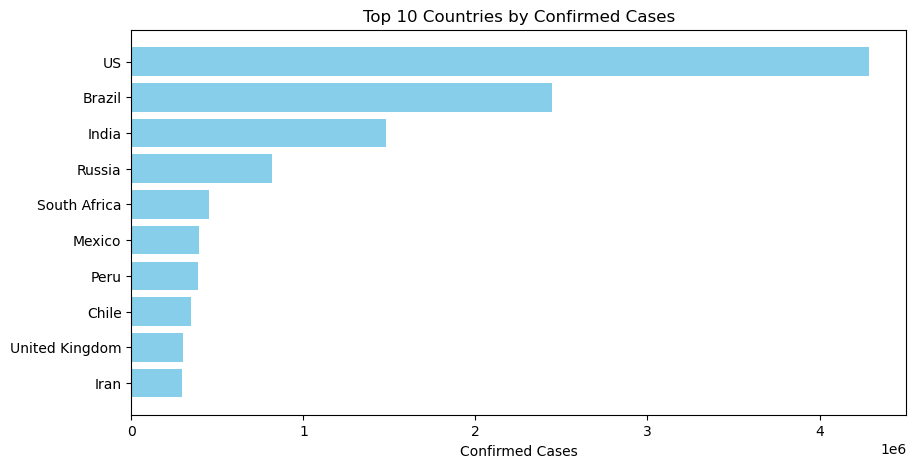

In [12]:
top_confirmed = df.sort_values(by='Confirmed', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_confirmed['Country/Region'], top_confirmed['Confirmed'], color='skyblue')
plt.xlabel("Confirmed Cases")
plt.title("Top 10 Countries by Confirmed Cases")
plt.gca().invert_yaxis()
plt.show()

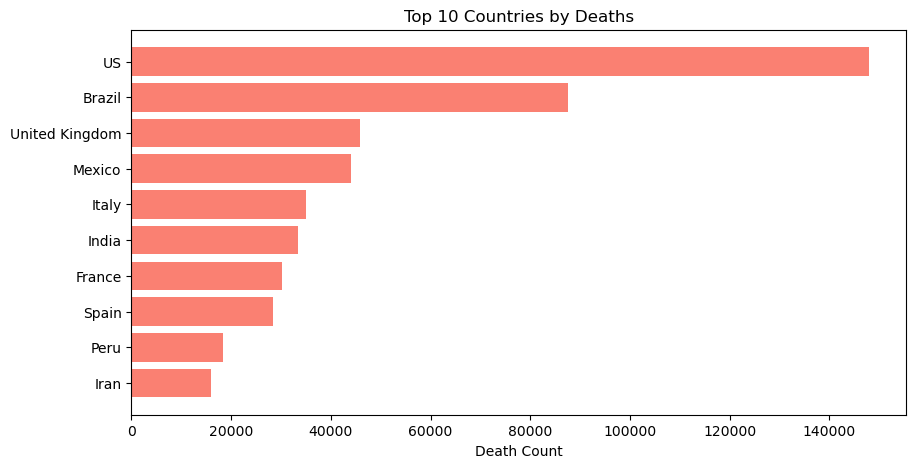

In [13]:
top_deaths = df.sort_values(by='Deaths', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.barh(top_deaths['Country/Region'], top_deaths['Deaths'], color='salmon')
plt.xlabel("Death Count")
plt.title("Top 10 Countries by Deaths")
plt.gca().invert_yaxis()
plt.show()

In [14]:
reg=df["WHO Region"].value_counts()
reg
fig=px.bar(x=reg.index,y=reg.values,title='Number of Countries per WHO Region',
       color=reg.index,
       labels={'x': 'WHO Region', 'y': 'Number of Countries'}
       )

fig

In [15]:
count_in_europe=df[["Country/Region","Confirmed"]][df["WHO Region"]=="Europe"].sort_values(by="Confirmed",ascending=False).head(10)
px.bar(count_in_europe,x="Country/Region",y="Confirmed",
       title="Top 10 countries with the highest number of infected cases in Europa",
       color="Country/Region",
       text="Confirmed"
       ).update_traces(textposition="outside").update_layout(height=560)

# Russia is the most country Registration of cases

In [17]:
count_in_europe=df[["Country/Region","Deaths"]][df["WHO Region"]=="Europe"].sort_values(by="Deaths",ascending=False).head(10)
px.bar(count_in_europe,x="Country/Region",y="Deaths",
       title="Top 10 countries with the highest number of Deaths in Europa",
       color="Country/Region",
       text="Deaths"
       )


In [18]:
df['Mortality Rate'] = (df['Deaths'] / df['Confirmed'] * 100).round(2)
reg=df[["Country/Region","Mortality Rate"]][df["WHO Region"]=="Europe"].sort_values(by="Mortality Rate",ascending=False).head(10)
px.line(reg, x='Country/Region', y='Mortality Rate', 
              markers=True,
              title='Top 10 Countries with Highest Mortality Rate Europe',
              labels={'Country': 'Country', 'Mortality Rate': 'Mortality Rate (%)'},
              line_shape='linear')
# UK has the Highest Mortality Rate

In [19]:
Confirmed=df[["Country/Region","Confirmed"]].sort_values(by="Confirmed",ascending=False)
Confirmed=Confirmed.head(10)

px.bar(Confirmed,x="Country/Region",y="Confirmed",
       title="Top 10 countries with the highest number of infected cases",
       color="Country/Region",
       text="Confirmed"
       ).update_traces(textposition="outside").update_layout(height=560)
# US is the country with the highest number of infected cases.

In [20]:
reg=df[["Country/Region","1 week % increase","WHO Region"]].sort_values(by="1 week % increase",ascending=False).head(10)
fig = px.bar(reg, x="Country/Region", y="1 week % increase",
             title="Top 10 countries with the highest weekly increase in confirmed cases",
             text="1 week % increase", color="WHO Region",)

fig.update_traces(texttemplate='%{text:.2f}%', textposition="outside")
fig.update_layout(showlegend=True,height=700)
fig.show()

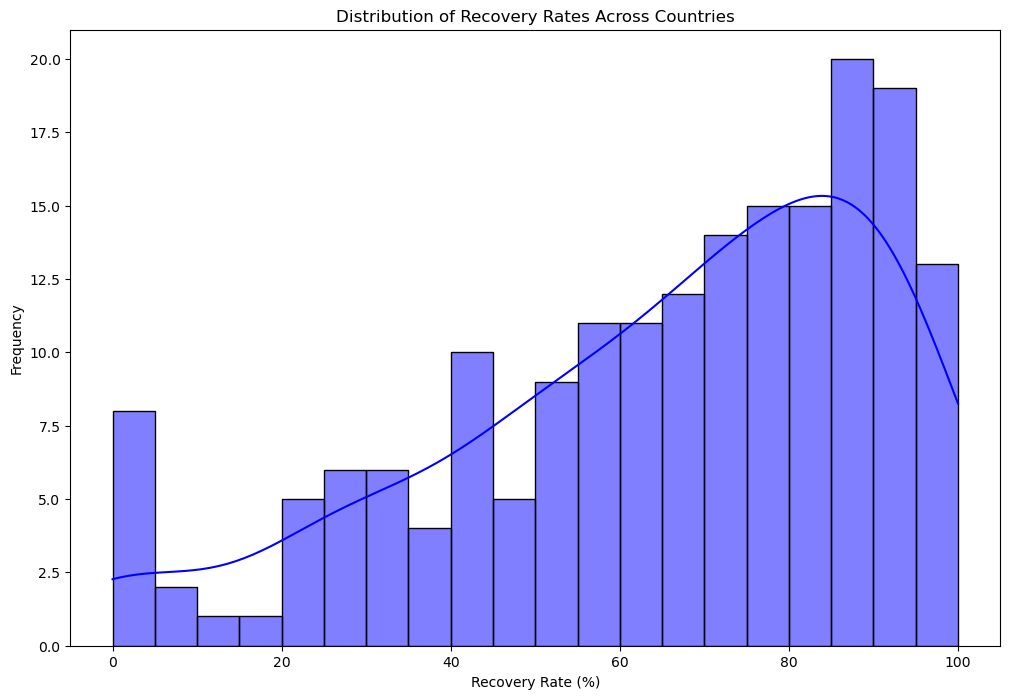

In [21]:
plt.figure(figsize=(12, 8))
sns.histplot(df['Recovered / 100 Cases'], bins=20, kde=True, color='blue')
plt.xlabel("Recovery Rate (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Recovery Rates Across Countries")
plt.show()

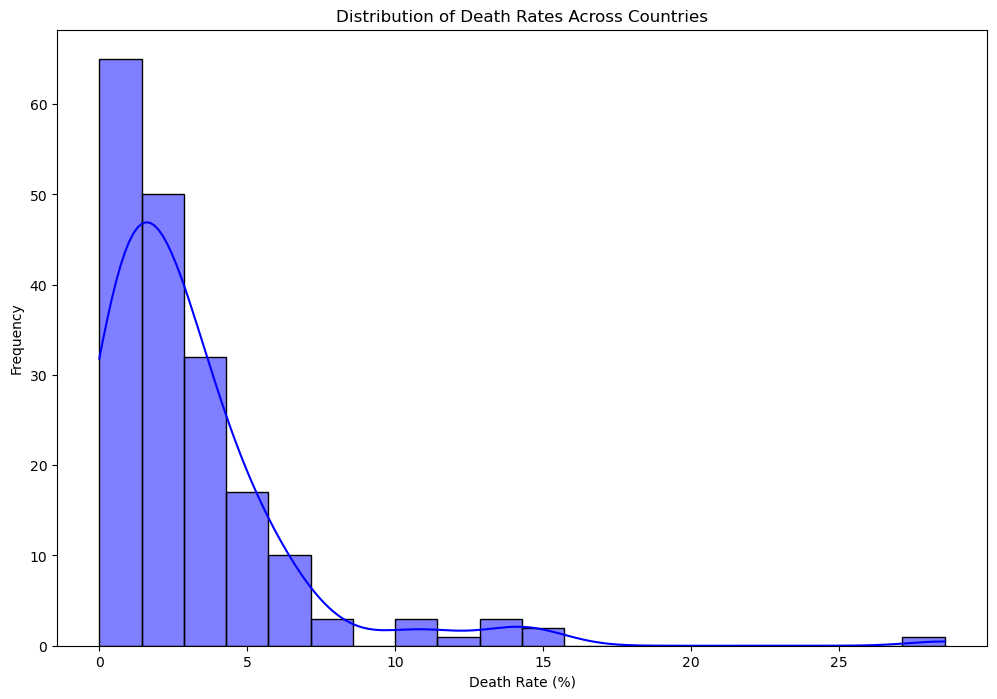

In [22]:
plt.figure(figsize=(12, 8))
sns.histplot(df['Deaths / 100 Cases'], bins=20, kde=True, color='blue')
plt.xlabel("Death Rate (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Death Rates Across Countries")
plt.show()

In [23]:
zero_active = df[df['Active'] == 0]
zero_active

,Country/Region,Confirmed,Deaths,Recovered,Active,New cases,New deaths,New recovered,Deaths / 100 Cases,Recovered / 100 Cases,Deaths / 100 Recovered,Confirmed last week,1 week change,1 week % increase,WHO Region,Mortality Rate
24,Brunei,141,3,138,0,0,0,0,2.13,97.87,2.17,141,0,0.0,Western Pacific,2.13
49,Dominica,18,0,18,0,0,0,0,0.00,100.00,0.00,18,0,0.0,Americas,0.00
69,Grenada,23,0,23,0,0,0,0,0.00,100.00,0.00,23,0,0.0,Americas,0.00
75,Holy See,12,0,12,0,0,0,0,0.00,100.00,0.00,12,0,0.0,Europe,0.00
143,San Marino,699,42,657,0,0,0,0,6.01,93.99,6.39,699,0,0.0,Europe,6.01


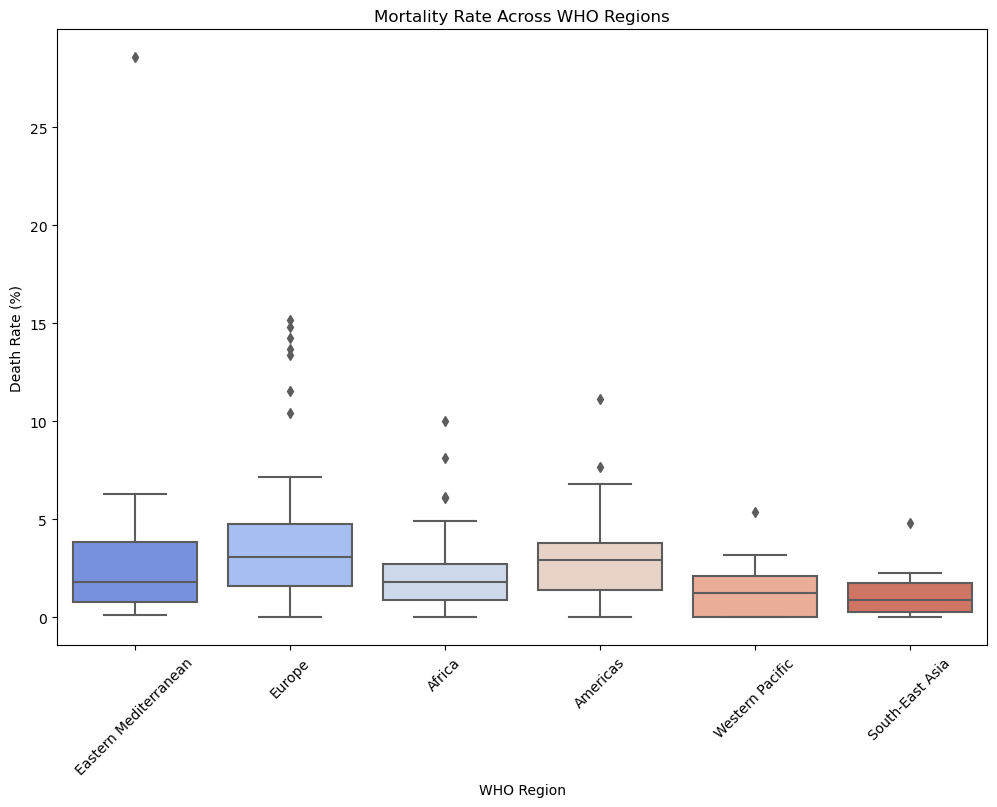

In [24]:
plt.figure(figsize=(12, 8))
sns.boxplot(x=df['WHO Region'], y=df['Deaths / 100 Cases'], palette='coolwarm')
plt.xlabel("WHO Region")
plt.ylabel("Death Rate (%)")
plt.title("Mortality Rate Across WHO Regions")
plt.xticks(rotation=45)
plt.show()

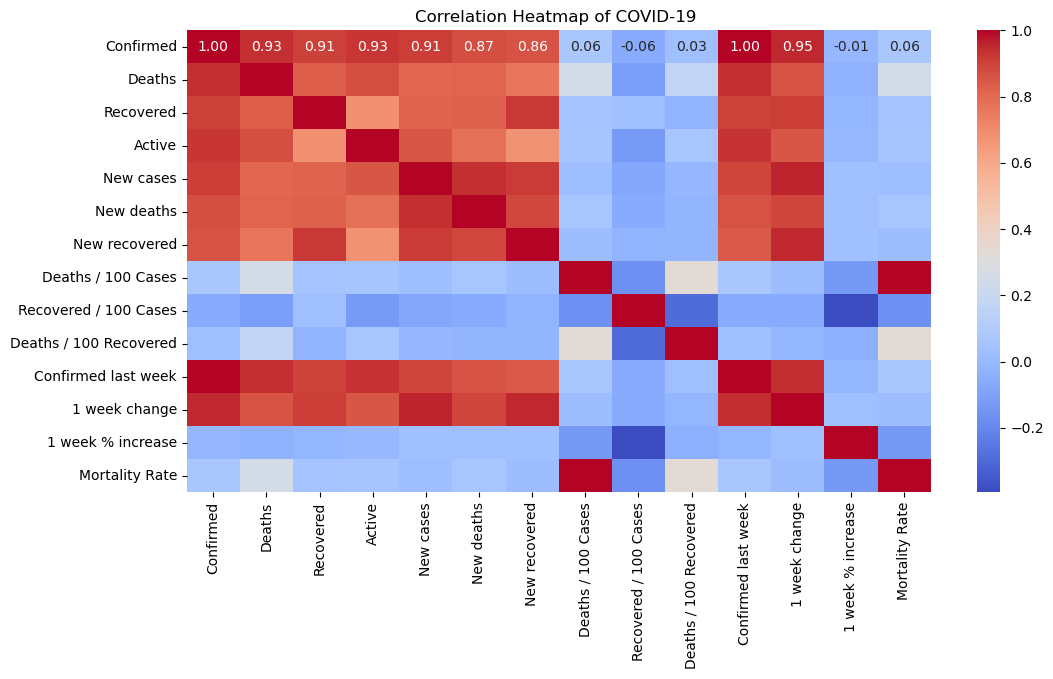

In [25]:
numeric_df = df.select_dtypes(include=['number'])


plt.figure(figsize=(12, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of COVID-19 ")
plt.show()

In [ ]:
######## ✔️ The USA, Brazil, and India are among the most affected countries in terms of confirmed COVID-19 cases.

✔Some countries show high death rates per 100 cases, indicating either healthcare system pressure or reporting issues.

✔Recovery rates vary widely, with several countries achieving recovery rates above 90%.

✔The weekly % increase highlights countries where COVID-19 is still actively spreading and becoming a concern.

✔A few countries show very low or no new cases, suggesting that they have effectively contained the virus.